# Latent Space Robustness

In this notebook, we explore the different metrics we can measure to analyze embedding space alignment, meaning how close are two representations produced by different neural networks.

In [3]:
import sys
sys.path.append('../../')
import os
import json
import torch
import transformers
import torch.nn as nn
from polygene.model.model import Polygene, load_trained_model
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

model_config = transformers.AutoConfig.from_pretrained("../model/polygene_architecture_classification.json")

model_config.vocab_size = int(12e2)
model_config.type_vocab_size = int(5e4)
model_config.pad_token_id = 2
model_config.classification_token = True

model_config.obs_included_phenotypes = ['disease', 'tissue', 'cell_type', 'sex', 'development_stage', 'assay',]
model_config.phenotypic_tokens_map = json.load(open("../data_utils/vocab/cxg_phenotypic_tokens_map.json"))
model_config.n_bins = 10
model = Polygene._from_config(model_config)

def num_params(module):
    total = sum(p.numel() for p in module.parameters())
    print(next((f"{total/t:.3f}{u}" for t,u in [(1e6,"M"),(1e3,"K")] if total>=t), total))

num_params(model)

27.189M


In [ ]:
'../../runs/polygene_cls_run_41/'

In [ ]:
model, tokenizer = load_trained_model('/media/lleger/LaCie/seeds_experiment/polygene_0/')

tokenizer.bypass_inference = True
from polygene.eval.metrics import prepare_cell, test_batch
import torch.nn.functional as F

from polygene.data_utils.data_collators import collate_fn_wrapper
import scanpy as sc
temperature=1e-2
cell_data = sc.read_h5ad('../../data/test_cxg.h5ad')    
y, y_pred = [], []

output_representations = []
phene=1
for cell in cell_data[:100]:
    prepared_cells = []
    prepared_cell = prepare_cell(cell, tokenizer)
    prepared_cell["labels"] = prepared_cell['input_ids'].detach().clone()
    prepared_cell["input_ids"][phene:phene+len(tokenizer.phenotypic_types)] = tokenizer.convert_tokens_to_ids(tokenizer.mask_token)


    y.append(prepared_cell['str_labels'][phene:phene+len(tokenizer.phenotypic_types)])
    del prepared_cell['str_labels']
    prepared_cells.append(prepared_cell)
    output = test_batch(prepared_cells, model, collate_fn_wrapper(tokenizer)) # (B, V)
    output_representations.append(output.hidden_states[:, 0])
    probabilities = F.softmax(output.logits[:, phene:phene+len(tokenizer.phenotypic_types)] / temperature, dim=-1)
    y_pred.append([tokenizer.flattened_tokens[torch.distributions.Categorical(phene_probabilities).sample().item()] 
                    for probability in probabilities for phene_probabilities in probability])
output_representations = np.concatenate(output_representations)

torch.Size([100, 5004, 1107])


In [43]:
(np.array(y) == np.array(y_pred).reshape(-1, 6)).mean()

0.8833333333333333

In [22]:
from polygene.eval.attribution import GeneAttribution
from polygene.eval.metrics import accuracy_table
model_paths = ['../../runs/gesam_polygene_run_4/', '../../runs/polygene_cls_run_41/']
X = []
for idx, path in enumerate(model_paths):
    m, tok = load_trained_model(path)
    tok.bypass_inference=True
    display(accuracy_table(m, tok, '../../data/test_cxg.h5ad', masking=True, n_cells=50))
    #a = GeneAttribution(sm, tok)
    #a.get_phenotype_cells(['../../data/test_cxg.h5ad'], sex=['male', 'female'], n=100)
    #X.append(a.get_embeddings(phenotype="disease", mask=True, classification_token=True if idx==1 else False)[0])
    #print((a.embeddings[1] == a.embeddings[2]).mean())

Some weights of the model checkpoint at ../../runs/gesam_polygene_run_4/checkpoint-2300000 were not used when initializing Polygene: ['prediction_head.2.bias', 'prediction_head.2.weight', 'prediction_head.3.bias', 'prediction_head.3.weight']
- This IS expected if you are initializing Polygene from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Polygene from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Polygene were not initialized from the model checkpoint at ../../runs/gesam_polygene_run_4/checkpoint-2300000 and are newly initialized because the shapes did not match:
- prediction_head.0.bias: found shape torch.Size([256]) in the checkpoint and torch.Size([1087]) in the model instantiate

,cell_type,sex,development_stage,tissue,disease
Top@1,0.0,0.0,0.10,0.0,0.0
Top@1-Mask,0.0,0.0,0.10,0.0,0.0
Top@5,0.0,0.0,0.26,0.0,0.0
Top@5-Mask,0.0,0.0,0.26,0.0,0.0


100%|██████████| 500/500.0 [01:58<00:00,  4.23it/s]


,cell_type,sex,development_stage,tissue,disease
Top@1,0.28,0.94,0.48,0.20,0.64
Top@1-Mask,0.28,0.94,0.48,0.20,0.64
Top@5,0.70,0.94,0.50,0.34,0.86
Top@5-Mask,0.70,0.94,0.50,0.34,0.86


In [ ]:
def linear_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)

    XTX = X.T @ X
    YTY = Y.T @ Y

    numerator = np.trace(XTX @ YTY)
    denominator = np.sqrt(np.trace(XTX @ XTX) * np.trace(YTY @ YTY))
    return numerator / denominator

from sklearn.decomposition import TruncatedSVD
from sklearn.cross_decomposition import CCA

def svcca(X, Y, dim=20):
    if X.shape[0] != Y.shape[0]:
        raise ValueError("X and Y must have the same number of samples")
    dim = max(1, min(dim, X.shape[0], X.shape[1], Y.shape[1]))
    Xr = TruncatedSVD(n_components=dim).fit_transform(X)
    Yr = TruncatedSVD(n_components=dim).fit_transform(Y)
    Xc, Yc = CCA(n_components=dim, max_iter=1000).fit_transform(Xr, Yr)
    C = np.corrcoef(Xc.T, Yc.T)
    return float(np.mean(np.diag(C[:dim, dim:])))

from sklearn.metrics import pairwise_distances

def mutual_knn(X, Y, k=10):
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)


print(X[0].shape, X[1].shape)
for func in [linear_cka, svcca, mutual_knn]:
    print(func(X[0], X[1]))

(200, 256) (200, 256)
0.085400075
0.460934911567853
0.21450000000000002


In [37]:
import numpy as np
import torch
import torch.nn.functional as F
import scanpy as sc
from polygene.eval.metrics import prepare_cell, test_batch
from polygene.data_utils.data_collators import collate_fn_wrapper
from sklearn.decomposition import TruncatedSVD
from sklearn.cross_decomposition import CCA
from sklearn.metrics import pairwise_distances

def linear_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    XTX = X.T @ X
    YTY = Y.T @ Y
    numerator = np.trace(XTX @ YTY)
    denominator = np.sqrt(np.trace(XTX @ XTX) * np.trace(YTY @ YTY))
    return numerator / denominator

def svcca(X, Y, dim=20):
    if X.shape[0] != Y.shape[0]:
        raise ValueError("X and Y must have the same number of samples")
    dim = max(1, min(dim, X.shape[0], X.shape[1], Y.shape[1]))
    Xr = TruncatedSVD(n_components=dim).fit_transform(X)
    Yr = TruncatedSVD(n_components=dim).fit_transform(Y)
    Xc, Yc = CCA(n_components=dim, max_iter=1000).fit_transform(Xr, Yr)
    C = np.corrcoef(Xc.T, Yc.T)
    return float(np.mean(np.diag(C[:dim, dim:])))

def mutual_knn(X, Y, k=5):
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

cell_data = sc.read_h5ad('/media/rohola/ssd_storage/primary/cxg_chunk1002.h5ad')
temperature = 1e-2
phene = 1
X = []

for gene_id in [0, 1]:
    model, tokenizer = load_trained_model(f'/media/lleger/LaCie/seeds_experiment/polygene_{gene_id}/', checkpoint_n=3)
    tokenizer.bypass_inference = True

    output_representations = []
    for cell in cell_data[:1000]:
        prepared_cell = prepare_cell(cell, tokenizer)
        prepared_cell["labels"] = prepared_cell['input_ids'].detach().clone()
        prepared_cell["input_ids"][phene:phene+len(tokenizer.phenotypic_types)] = tokenizer.convert_tokens_to_ids(tokenizer.mask_token)
        del prepared_cell['str_labels']
        output = test_batch([prepared_cell], model, collate_fn_wrapper(tokenizer))
        output_representations.append(output.hidden_states[:, 0].detach().cpu().numpy())
    X.append(np.concatenate(output_representations))


In [45]:
print(X[0].shape, X[1].shape)
from sklearn.preprocessing import RobustScaler

Xr = RobustScaler().fit_transform(X[0])
Yr = RobustScaler().fit_transform(X[1])
print( cka_linear(Xr, Yr) )
def cka_linear(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    numerator = np.sum(K*L)
    denominator = np.sqrt(np.sum(K*K)*np.sum(L*L))
    return numerator/denominator
for func in [cka_linear, svcca, mutual_knn]:
    print(func(X[0], X[1]))

(1000, 192) (1000, 192)
0.8633907462158982
0.8860028484488901
0.8134191475270562
0.7696000000000001


In [39]:
from scipy.spatial import procrustes
import numpy as np

# X and Y are two embeddings of the same samples
mtx1, mtx2, disparity = procrustes(Xr, Yr)

print("Aligned shapes:", mtx1.shape, mtx2.shape)
print("Procrustes distance:", disparity)

Aligned shapes: (1000, 192) (1000, 192)
Procrustes distance: 0.27836800610848905


In [44]:
X_uniform = [
    np.random.uniform(size=X[0].shape),
    np.random.uniform(size=X[1].shape)
]


def cka_linear(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    numerator = np.sum(K*L)
    denominator = np.sqrt(np.sum(K*K)*np.sum(L*L))
    return numerator/denominator

def cka_linear(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    numerator = np.sum(K * L)
    denominator = np.sqrt(np.sum(K*K) * np.sum(L*L))
    return numerator / denominator

def mutual_knn(X, Y, k=5):
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

print("Random uniform baseline:")
for func in [cka_linear, svcca, mutual_knn]:
    print(func(X_uniform[0], X_uniform[1]))
    print(func(X[0], X[1]))

Random uniform baseline:
0.16089404343871605
0.8860028484488901
0.11598455171041992
0.8120216325588567
0.0058
0.7696000000000001


In [47]:
from scipy.spatial import procrustes
import numpy as np

def cka_linear(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    numerator = np.sum(K * L)
    denominator = np.sqrt(np.sum(K*K) * np.sum(L*L))
    return numerator / denominator

def combined_metric(X, Y):
    cka_score = cka_linear(X, Y)
    _, _, disparity = procrustes(X, Y)
    procrustes_score = 1 - disparity
    if cka_score > 0 and procrustes_score > 0:
        return 2 * (cka_score * procrustes_score) / (cka_score + procrustes_score)
    else:
        return 0.0

def baseline_test(X, Y, repeats=500, rng=None):
    rng = np.random.default_rng(rng)
    obs = combined_metric(X, Y)
    null_scores = []
    for _ in range(repeats):
        Y_perm = Y[rng.permutation(Y.shape[0])]
        null_scores.append(combined_metric(X, Y_perm))
    null_scores = np.array(null_scores)
    z = (obs - null_scores.mean()) / null_scores.std()
    return obs, z, null_scores, null_scores.mean(), null_scores.std()

obs, z, null, mean_null, std_null = baseline_test(X[0], X[1])
print("Observed:", obs)
print("Null mean:", mean_null)
print("Null std:", std_null)
print("p_value:", (np.sum(null >= obs) + 1) / (len(null) + 1))
print("Z-score:", z)

Observed: 0.8048674955655718
Null mean: 0.056072342515997124
Null std: 0.0012712502819832486
p_value: 0.001996007984031936
Z-score: 589.022605274389


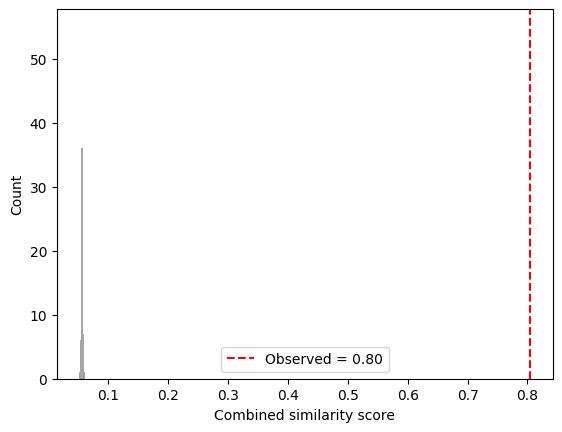

In [48]:
import matplotlib.pyplot as plt

plt.hist(null, bins=30, color="gray", alpha=0.7)
plt.axvline(obs, color="red", linestyle="--", label=f"Observed = {obs:.2f}")
plt.xlabel("Combined similarity score")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
def unbiased_cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)
    K = X @ X.T
    L = Y @ Y.T
    n = K.shape[0]
    np.fill_diagonal(K, 0)
    np.fill_diagonal(L, 0)
    hsic = np.trace(K @ L) / (n * (n - 3)) - 2 * np.sum(K) * np.sum(L) / (n * (n - 2) * (n - 3))
    norm_x = np.trace(K @ K) / (n * (n - 3))
    norm_y = np.trace(L @ L) / (n * (n - 3))
    return hsic / np.sqrt(norm_x * norm_y)

In [ ]:
from polygene.eval.attribution import GeneAttribution
a = GeneAttribution(m, tok)
a.get_phenotype_cells(['../../data/test_cxg.h5ad'], sex=['male', 'female'])
a.get_embeddings(phenotype="disease", mask=True)